# Analyze RL Trajectories

Load trajectories saved by `rl/experiments/compare_pretrained_rl_atoms.py`, summarize them, deduplicate final molecules, and visualize selected trajectories.


In [6]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw


def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repository root (missing pyproject.toml in parents)")


PROJECT_ROOT = find_repo_root(Path.cwd())
for p in [str(PROJECT_ROOT), str(PROJECT_ROOT / "src")]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"PROJECT_ROOT={PROJECT_ROOT}")

PROJECT_ROOT=/network/scratch/g/goldszaa/chemflow


In [7]:
# Adjust this path if you saved trajectories elsewhere.
TRAJ_PATH = PROJECT_ROOT / "rl" / "experiments" / "natoms" / "grpo_natoms_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_maxa100-continue3-omitposkl_scaff_b10_p0p5_w50_canonsmi_best" / "rl_valid_trajectories.pt"

if not TRAJ_PATH.exists():
    raise FileNotFoundError(
        f"Trajectory file not found at {TRAJ_PATH}. "
        "Run compare_pretrained_rl_atoms.py first, or update TRAJ_PATH."
    )

blob = torch.load(str(TRAJ_PATH), weights_only=False)
records = blob.get("records", [])

print(f"Loaded: {TRAJ_PATH}")
print(f"Saved records: {len(records)}")

Loaded: /network/scratch/g/goldszaa/chemflow/rl/experiments/natoms/grpo_natoms_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_maxa100-continue3-omitposkl_scaff_b10_p0p5_w50_canonsmi_best/rl_valid_trajectories.pt
Saved records: 255


In [8]:
import time

_t0 = time.perf_counter()
print("Cell 3: starting atom-count summary...")

if records is None:
    records = []

if not isinstance(records, list):
    print(f"records is {type(records).__name__}; materializing to a list now...")
    records = list(records)

print(f"records type={type(records).__name__}, n={len(records)}")

if not records:
    print("No records found.")
else:
    atom_values = []
    for i, r in enumerate(records):
        try:
            atom_values.append(int(r["final_n_atoms"]))
        except Exception as exc:
            keys = list(r.keys()) if isinstance(r, dict) else None
            print(f"Failed to parse record {i}: type={type(r).__name__}, keys={keys}")
            raise RuntimeError(f"Bad record at index {i}") from exc

    atom_counts = np.array(atom_values, dtype=int)
    counter = Counter(atom_counts.tolist())

    print("=== Metadata ===")
    print("rl_ckpt:", blob.get("rl_ckpt"))
    print("pretrained_ckpt:", blob.get("pretrained_ckpt"))
    print("n_mols_requested:", blob.get("n_mols_requested"))
    print("min_atoms:", blob.get("min_atoms"))
    print("rl_validity:", blob.get("rl_validity"))

    print("\n=== Atom-count stats over saved records ===")
    print("count:", int(atom_counts.size))
    print("mean:", float(atom_counts.mean()))
    print("median:", float(np.median(atom_counts)))
    print("min:", int(atom_counts.min()))
    print("max:", int(atom_counts.max()))

    print("\n=== Frequency (top 15 atom counts) ===")
    for n_atoms, freq in sorted(counter.items(), key=lambda kv: (-kv[1], -kv[0]))[:15]:
        print(f"n_atoms={n_atoms:>3} -> {freq}")

print(f"Cell 3: done in {time.perf_counter() - _t0:.3f}s")

Cell 3: starting atom-count summary...
records type=list, n=255
=== Metadata ===
rl_ckpt: /network/scratch/g/goldszaa/chemflow/.rl_ckpts/grpo_natoms_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_maxa100-continue3-omitposkl_scaff_b10_p0p5_w50_canonsmi_best.pt
pretrained_ckpt: /network/scratch/g/goldszaa/chemflow/.pretrained_model/epoch=499-step=48500.ckpt
n_mols_requested: 300
min_atoms: 32
rl_validity: 0.85

=== Atom-count stats over saved records ===
count: 255
mean: 61.819607843137256
median: 61.0
min: 54
max: 70

=== Frequency (top 15 atom counts) ===
n_atoms= 61 -> 41
n_atoms= 60 -> 38
n_atoms= 64 -> 35
n_atoms= 63 -> 27
n_atoms= 58 -> 27
n_atoms= 67 -> 20
n_atoms= 57 -> 14
n_atoms= 66 -> 12
n_atoms= 62 -> 12
n_atoms= 59 -> 10
n_atoms= 65 -> 8
n_atoms= 70 -> 3
n_atoms= 69 -> 3
n_atoms= 55 -> 3
n_atoms= 56 -> 1
Cell 3: done in 0.002s


## Vocab and RDKit helpers


In [9]:
import hydra
from rl.eval_pretrained_validity import compose_cfg

# OmegaConf in our Hydra config uses ${oc.env:PROJECT_ROOT}.
os.environ.setdefault("PROJECT_ROOT", str(PROJECT_ROOT))

# We only need vocab for trajectory -> RDKit conversion.
# Instantiate preprocessing directly to avoid building the full model on CUDA.
cfg = compose_cfg(str(PROJECT_ROOT / "configs"), "default", overrides=blob.get("hydra_overrides", []))
preprocessing = hydra.utils.instantiate(cfg.data.preprocessing)
vocab = preprocessing.vocab


def final_mol_from_record(record, vocab):
    final_frame = record["trajectory"][-1]
    return final_frame.to_rdkit_mol(vocab.atom_tokens, vocab.edge_tokens, vocab.charge_tokens)


def current_records_for_viz():
    """Use deduplicated records after the uniqueness cell has run; otherwise use all records."""
    return records_for_viz if "records_for_viz" in globals() else records


## Molecules with heteroatoms


In [10]:
# Final-frame heteroatoms: any atom symbol outside {C, H}.
ALLOWED_ATOMS = frozenset({"C", "H"})


def final_atom_symbols(record, vocab) -> list[str]:
    final_frame = record["trajectory"][-1]
    n = int(final_frame.num_nodes)
    atom_indices = final_frame.a.detach().cpu().reshape(-1)[:n].tolist()
    return [vocab.atom_tokens[int(ix)] for ix in atom_indices]


def records_with_heteroatoms(records_source, vocab, allowed_atoms=ALLOWED_ATOMS):
    hetero_records = []
    examples = []  # (record_idx, sorted non-CH symbols, final_n_atoms)

    for idx, rec in enumerate(records_source):
        symbols = final_atom_symbols(rec, vocab)
        hetero_symbols = sorted({s for s in symbols if s not in allowed_atoms})
        if not hetero_symbols:
            continue
        hetero_records.append(rec)
        examples.append((idx, hetero_symbols, int(rec.get("final_n_atoms", len(symbols)))))

    return hetero_records, examples


final_hetero_records, hetero_examples = records_with_heteroatoms(records, vocab)
n_total = len(records)
pct = 100.0 * len(final_hetero_records) / n_total if n_total else 0.0

print(f"Molecules with any atom other than C or H: {len(final_hetero_records)} / {n_total} ({pct:.1f}%)")
if hetero_examples:
    print("Examples (record index, non-{C,H} symbols, final_n_atoms):")
    for row in hetero_examples[:8]:
        print(" ", row)
else:
    print("All saved finals are C/H-only (per vocab atom index -> token mapping).")


Molecules with any atom other than C or H: 0 / 255 (0.0%)
All saved finals are C/H-only (per vocab atom index -> token mapping).


In [11]:
import importlib

import notebooks.utils as _nb_utils

importlib.reload(_nb_utils)
from notebooks.utils import process_mol, visualize_single_mol, visualize_mols_side_by_side

# py3Dmol: final frames only, laid out side-by-side in one static scene.
WIDTH, HEIGHT = 950, 460
MAX_MOLS = 8
GAP = 4.0  # Angstrom between molecules along X

records_source = current_records_for_viz()
final_hetero_records_viz, _ = records_with_heteroatoms(records_source, vocab)

if not final_hetero_records_viz:
    print("No finals with heteroatoms (non-{C,H}) in this record list.")
else:
    selected = final_hetero_records_viz[:MAX_MOLS]
    frames = [
        process_mol(r["trajectory"][-1], vocab.atom_tokens, vocab.charge_tokens, vocab.edge_tokens)
        for r in selected
    ]
    if len(frames) == 1:
        view = visualize_single_mol(frames[0], width=WIDTH, height=HEIGHT)
    else:
        view = visualize_mols_side_by_side(frames, width=WIDTH, height=HEIGHT, gap=GAP)
    view.show()
    print(f"3D: {len(frames)} final molecule(s) in one view. Tune MAX_MOLS / GAP / WIDTH.")


No finals with heteroatoms (non-{C,H}) in this record list.


## Uniqueness check


In [12]:
# Optional deduplication: keep one record per unique final molecule (canonical SMILES).
# Downstream cells use records_for_viz if present.
# Also summarizes generic Murcko scaffolds (RDKit GetScaffoldForMol + MakeScaffoldGeneric),
# matching rl/rewards.scaffold_diversity_wrapper defaults (generic_scaffold=True).

def generic_murcko_smiles(mol: Chem.Mol) -> str | None:
    """Same chemistry as rl/rewards._murcko_scaffold_smiles(..., generic=True)."""
    try:
        from rdkit.Chem.Scaffolds import MurckoScaffold

        core = MurckoScaffold.GetScaffoldForMol(mol)
        if core is None:
            return None
        try:
            MurckoScaffold.MakeScaffoldGeneric(core)
        except Exception:
            pass
        return Chem.MolToSmiles(core)
    except Exception:
        return None


dedup_by_final_smiles = True

parsed: list[dict] = []
skipped_convert = 0

for rec in records:
    mol = final_mol_from_record(rec, vocab)
    if mol is None:
        skipped_convert += 1
        continue
    try:
        smiles = Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        skipped_convert += 1
        continue
    scaffold = generic_murcko_smiles(mol)
    parsed.append({"record": rec, "smiles": smiles, "scaffold": scaffold})

n_parsed = len(parsed)
n_scaffold_fail = sum(1 for p in parsed if p["scaffold"] is None)
scaffold_ok = [p["scaffold"] for p in parsed if p["scaffold"] is not None]
n_unique_smi = len({p["smiles"] for p in parsed})
n_unique_scaf = len(set(scaffold_ok))

print("=== Generic Murcko - RDKit-convertible records only ===")
print(f"records_total: {len(records)}")
print(f"skipped_rdkit_or_canonical_smiles: {skipped_convert}")
print(f"parsed_molecules: {n_parsed}")
print(f"generic_murcko_extract_fail: {n_scaffold_fail}")
print(f"unique_canonical_smiles: {n_unique_smi}")
print(f"unique_generic_murcko: {n_unique_scaf}")
if n_unique_smi and n_unique_scaf:
    print(f"unique_smiles / unique_murcko: {n_unique_smi / n_unique_scaf:.3f}")
if scaffold_ok:
    ctr_all = Counter(scaffold_ok)
    print(f"molecules_per_scaffold_mean: {len(scaffold_ok) / len(ctr_all):.3f}")
    print("top_10_generic_scaffolds_by_count (among parsed):")
    for i, (sc, c) in enumerate(ctr_all.most_common(10), 1):
        short = sc if len(sc) <= 72 else sc[:69] + "..."
        print(f"  {i:>2}  count={c:<4}  {short}")

if not dedup_by_final_smiles:
    records_for_viz = list(records)
    print(f"\nDedup disabled: using all {len(records_for_viz)} records")
    print(
        "(Murcko block above is over RDKit-convertible rows only; "
        "includes duplicate SMILES if present.)"
    )
else:
    unique_by_smiles: dict[str, dict] = {}
    for p in parsed:
        smi = p["smiles"]
        if smi not in unique_by_smiles:
            unique_by_smiles[smi] = {
                "record": p["record"],
                "count": 1,
                "scaffold": p["scaffold"],
            }
        else:
            unique_by_smiles[smi]["count"] += 1

    dedup_items = sorted(
        unique_by_smiles.items(),
        key=lambda kv: int(kv[1]["record"]["final_n_atoms"]),
        reverse=True,
    )
    records_for_viz = [item[1]["record"] for item in dedup_items]
    duplicate_count = len(records) - len(records_for_viz)

    print(f"\nInput records: {len(records)}")
    print(f"Unique final molecules: {len(records_for_viz)}")
    print(f"Dropped duplicates (record rows - unique SMILES kept): {duplicate_count}")
    if skipped_convert:
        print(f"Skipped non-convertible records: {skipped_convert}")

    dedup_scafs = [v["scaffold"] for v in unique_by_smiles.values() if v["scaffold"] is not None]
    print("\n=== Generic Murcko - unique final molecules (deduped by SMILES) ===")
    print(f"unique_molecules: {len(unique_by_smiles)}")
    print(f"unique_generic_murcko: {len(set(dedup_scafs))}")
    if dedup_scafs:
        ctr_d = Counter(dedup_scafs)
        print(f"molecules_per_scaffold_mean: {len(dedup_scafs) / len(ctr_d):.3f}")
        print("top_10_generic_scaffolds_by_count (dedup set):")
        for i, (sc, c) in enumerate(ctr_d.most_common(10), 1):
            short = sc if len(sc) <= 72 else sc[:69] + "..."
            print(f"  {i:>2}  count={c:<4}  {short}")


=== Generic Murcko - RDKit-convertible records only ===
records_total: 255
skipped_rdkit_or_canonical_smiles: 0
parsed_molecules: 255
generic_murcko_extract_fail: 0
unique_canonical_smiles: 237
unique_generic_murcko: 45
unique_smiles / unique_murcko: 5.267
molecules_per_scaffold_mean: 5.667
top_10_generic_scaffolds_by_count (among parsed):
   1  count=37    C1CCCCC1
   2  count=27    C1CC2CCC(C1)CC2
   3  count=20    C1CC2CCC(C1)C2
   4  count=20    C1CCCCCC1
   5  count=17    C1CCCC1
   6  count=15    C1CCC2CCC(C1)C2
   7  count=14    C1CCCCCCC1
   8  count=13    
   9  count=9     C1CC2CCC1CC2
  10  count=8     C1CCC2CCCC(C1)C2

Input records: 255
Unique final molecules: 237
Dropped duplicates (record rows - unique SMILES kept): 18

=== Generic Murcko - unique final molecules (deduped by SMILES) ===
unique_molecules: 237
unique_generic_murcko: 45
molecules_per_scaffold_mean: 5.267
top_10_generic_scaffolds_by_count (dedup set):
   1  count=36    C1CCCCC1
   2  count=22    C1CC2CCC(C1)

## Size check


Rendering 64 molecule(s) from deduplicated records.


/home/mila/g/goldszaa/scratch/chemflow/.venv/lib/python3.10/site-packages/rdkit/Chem/Draw/IPythonConsole.py:376: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


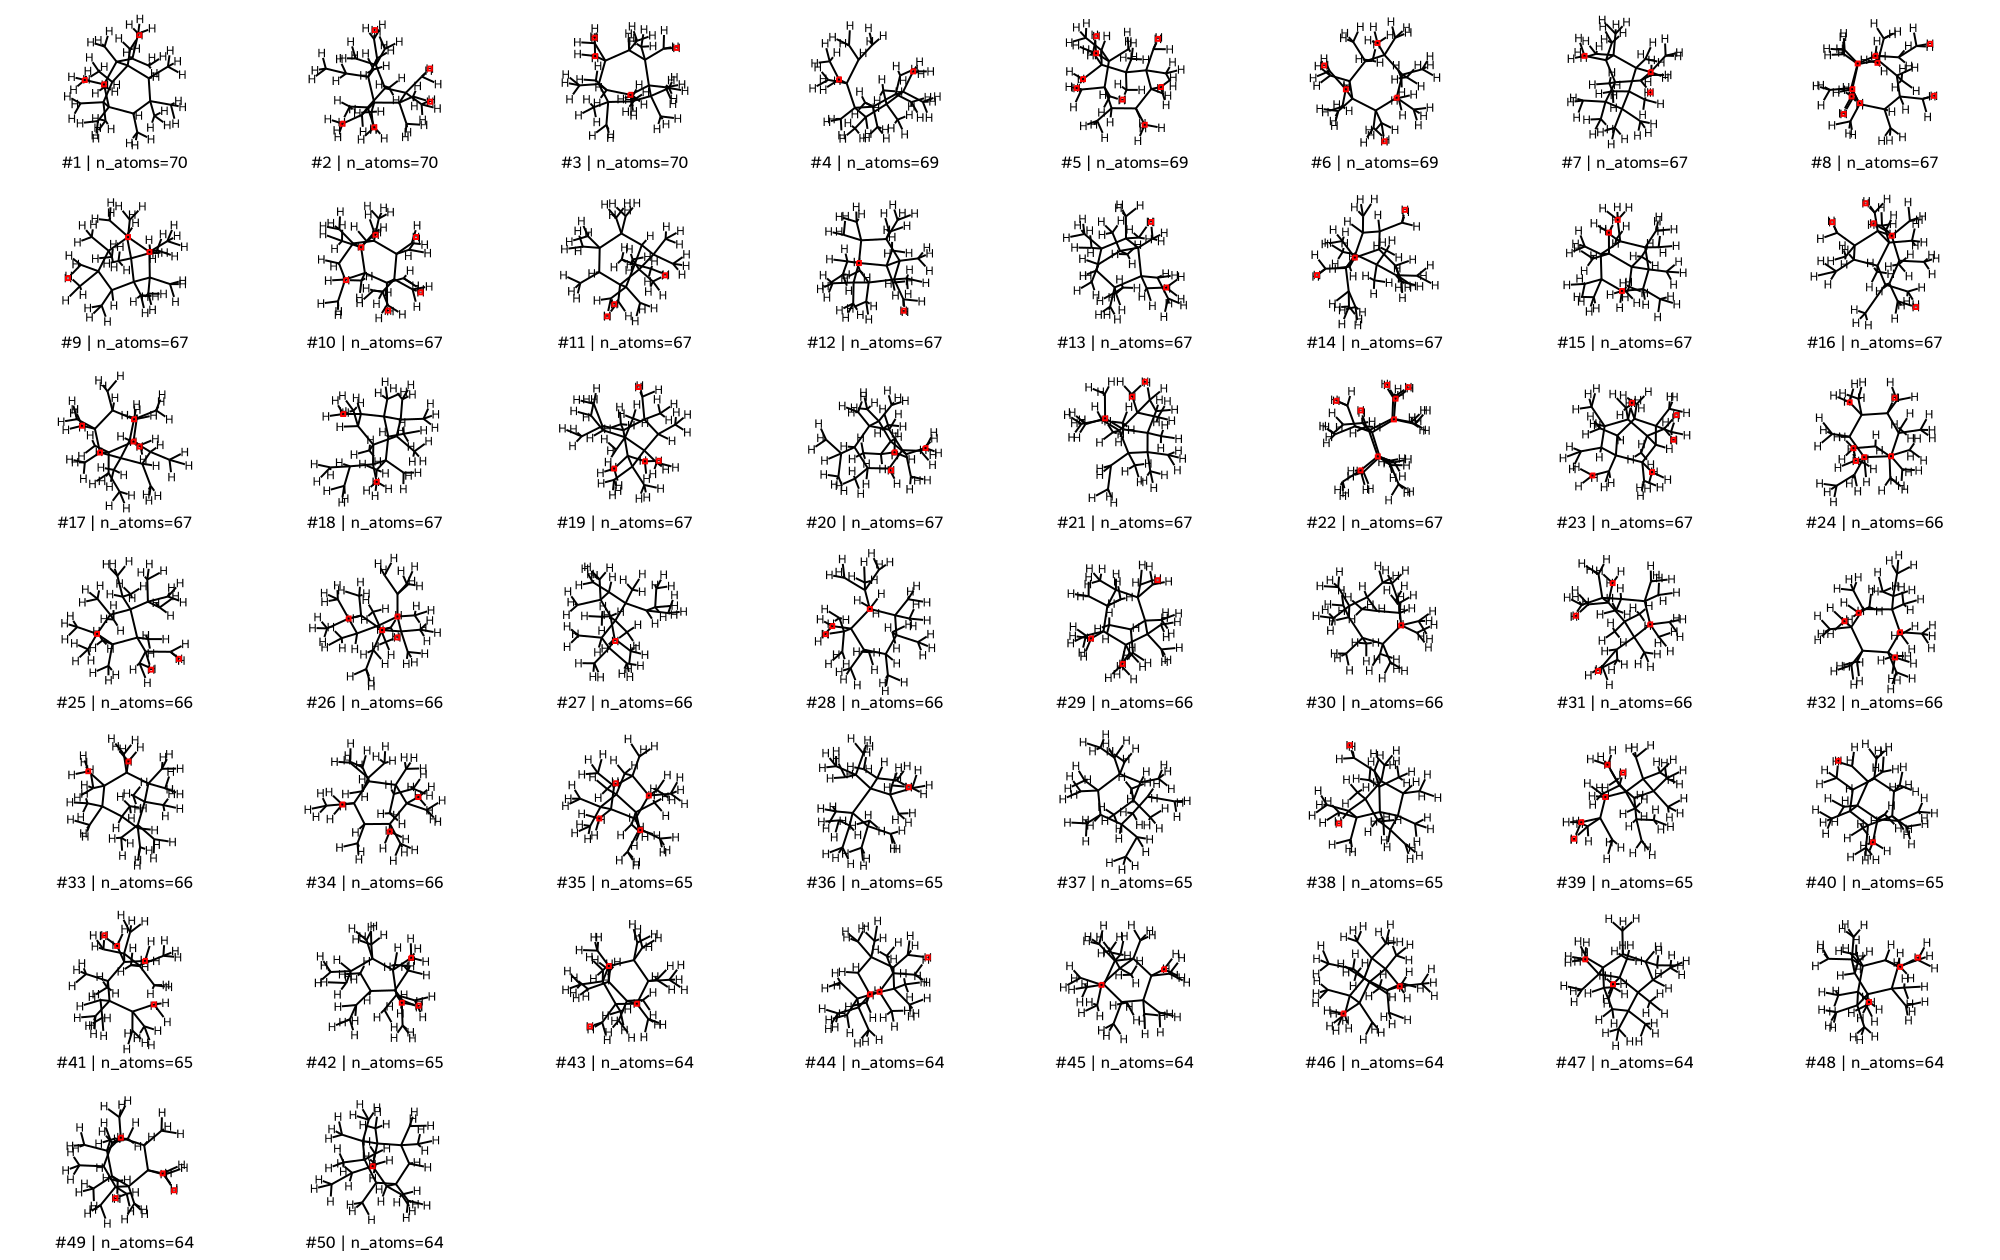

In [13]:
# Show molecules sorted by decreasing number of atoms.
# Tune this to render more/less molecules.
TOP_K = 64
MOLS_PER_ROW = 8
IMG_SIZE = (250, 180)

records_source = current_records_for_viz()
source_label = "deduplicated records" if "records_for_viz" in globals() else "all records"
records_sorted = sorted(records_source, key=lambda r: int(r["final_n_atoms"]), reverse=True)
selected = records_sorted[:TOP_K]

mols = []
legends = []
for i, rec in enumerate(selected):
    mol = final_mol_from_record(rec, vocab)
    if mol is None:
        continue
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        pass
    mols.append(mol)
    legends.append(f"#{i+1} | n_atoms={int(rec['final_n_atoms'])}")

if not mols:
    print("No molecules could be rendered.")
else:
    print(f"Rendering {len(mols)} molecule(s) from {source_label}.")
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=MOLS_PER_ROW,
        subImgSize=IMG_SIZE,
        legends=legends,
        useSVG=True,
    )
    display(img)


## Viz


Trajectory #1: frames=200, final_n_atoms=70


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

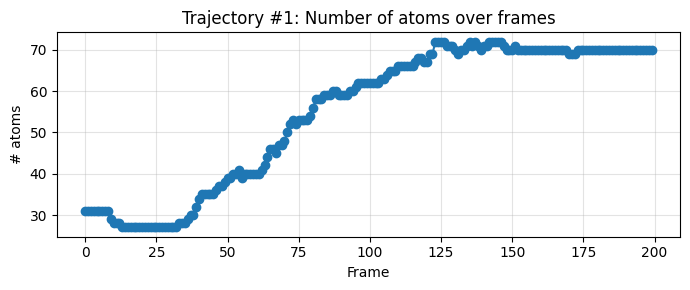

In [ ]:
import matplotlib.pyplot as plt
from notebooks.utils import process_mol, visualize_variable_topology

# Pick which saved RL trajectory to inspect in 3D.
traj_idx = 1
ANIM_INTERVAL_MS = 50

records_source = current_records_for_viz()

if not records_source:
    print("No records available.")
elif traj_idx < 0 or traj_idx >= len(records_source):
    print(f"traj_idx={traj_idx} is out of range [0, {len(records_source) - 1}]")
else:
    rec = records_source[traj_idx]
    traj = rec["trajectory"]

    # Convert each frame into tokenized atom/edge dicts expected by visualize_variable_topology.
    traj_frames = [
        process_mol(frame, vocab.atom_tokens, vocab.charge_tokens, vocab.edge_tokens)
        for frame in traj
    ]

    print(
        f"Trajectory #{traj_idx}: frames={len(traj_frames)}, "
        f"final_n_atoms={int(rec.get('final_n_atoms', -1))}"
    )

    view = visualize_variable_topology(
        traj_frames,
        width=950,
        height=460,
        interval=ANIM_INTERVAL_MS,
    )
    view.show()

    num_atoms_per_frame = [len(frame["atoms"]) for frame in traj_frames]
    plt.figure(figsize=(7, 3))
    plt.plot(range(len(num_atoms_per_frame)), num_atoms_per_frame, marker="o", linewidth=1.5)
    plt.title(f"Trajectory #{traj_idx}: Number of atoms over frames")
    plt.xlabel("Frame")
    plt.ylabel("# atoms")
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()
